## Lib integration

In [1]:
import sys
# sys.path.append(r"E:\Dai hoc\2526I\dacn\flow-matching")
sys.path.append(r"E:\Dai hoc\2526I\dacn\flow-matching\demo-code\2d")
import h5py
from collections import defaultdict, Counter
import numpy as np
from rich import print

In [2]:
file_path = r"E:\Dai hoc\2526I\dacn\flow-matching\data\traintest_hcd.hdf5"

## Open data

In [3]:
with h5py.File(file_path, "r") as f:
    print("Keys:", list(f.keys()))

    seqs = f["sequence_integer"][:]
    charges_oh = f["precursor_charge_onehot"][:]
    intensities = f["intensities_raw"][:]  

Keys:
[
    'collision_energy',
    'collision_energy_aligned',
    'collision_energy_aligned_normed',
    'intensities_raw',
    'masses_pred',
    'masses_raw',
    'method',
    'precursor_charge_onehot',
    'rawfile',
    'reverse',
    'scan_number',
    'score',
    'sequence_integer',
    'sequence_onehot'
]

In [4]:
charges = np.argmax(charges_oh, axis=1) + 1
del charges_oh

In [5]:
seqs[0]

array([19,  4, 18, 20, 13, 18, 12, 16, 17,  5, 15, 18, 10, 18, 16,  6,  1,
       17, 15,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

### Utils

### Peak data

In [6]:
# np.argmax(charges_oh, axis=1) + 1

In [7]:
len(intensities[0])

174

In [8]:
# max_index = 0
# for seq in seqs:
#     for token in seq:
#         if token > max_index:
#             max_index = token
# print("Max token index:", max_index)

## Explore data

## FLow matching training

In [11]:
import torch
torch.set_default_device("cuda")
from torch import nn
# from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import imageio
from sklearn.datasets import make_moons
import math

from coupling import mini_batch_coupling, greedy_coupling, sinkhorm_coupling
from draw import DrawFlow, DrawSample
from gen_path import get_xt
from flow_model import HCDFlowResMLP, HCDFlow

### Training configuration

In [12]:
epoch = 4
batch_size = 512
model = HCDFlowResMLP(noise_dim=174, pep_dim=256, time_dim=128, charge_dim=128, num_blocks=10)
optimizer = torch.optim.AdamW(model.parameters(), eps=1e-10, lr=3e-4,weight_decay=1e-2)

#### Tranable params

In [13]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

5803086

In [14]:
# torch.save(model.state_dict(), "model.pth")

In [15]:
from tqdm.auto import tqdm
# pbar = tqdm(range(int(epoch)), desc="Training")
loss_history = []
last_100_loss = []
pbar = tqdm(range(int(epoch)), desc="Training")
num_samples = len(seqs)
num_batches = math.ceil(num_samples / batch_size)
for ep in pbar:
    model.train()
    
    for b in range(num_batches):
        start = b * batch_size
        end = min((b + 1) * batch_size, num_samples)

        batch_intensities = torch.tensor(
            intensities[start:end], dtype=torch.float32
        )
        batch_pep_seq = torch.tensor(
            seqs[start:end], dtype=torch.long
        )
        batch_charge = torch.tensor(
            charges[start:end], dtype=torch.float32
        ).unsqueeze(1)

        cur_bs = batch_intensities.shape[0]

        noise = torch.randn_like(batch_intensities)
        t = torch.rand(cur_bs, 1)

        x_t = get_xt(batch_intensities, noise, t)
        u_pred = model(x_t, t=t, pep_seq=batch_pep_seq, charge=batch_charge)

        loss = nn.MSELoss()(u_pred, batch_intensities - noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        last_100_loss.append(loss.item())

        if len(last_100_loss) == 100:
            mean_last_100 = sum(last_100_loss) / 100
            last_100_loss.clear()
            loss_history.append(mean_last_100)

            pbar.set_postfix({
                "Last100": f"{mean_last_100:.4f}",
                "Avg": f"{(sum(loss_history)/len(loss_history)):.4f}",
            })

Training:   0%|          | 0/4 [00:00<?, ?it/s]

KeyboardInterrupt: 

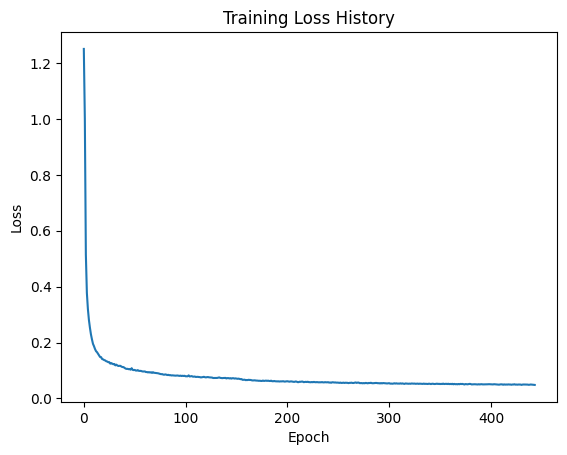

In [16]:
import matplotlib.pyplot as plt

def plot_loss_history(loss_history, smooth_window=None):
    """
    Plot training loss history.
    
    Args:
        loss_history (list or array): Danh sách loss theo từng step/epoch.
        smooth_window (int, optional): Nếu truyền vào, sẽ vẽ thêm đường smooth
                                       bằng moving average với window này.
    """
    plt.figure()
    plt.plot(loss_history)
    
    if smooth_window is not None and smooth_window > 1:
        import numpy as np
        loss_array = np.array(loss_history)
        kernel = np.ones(smooth_window) / smooth_window
        smooth_loss = np.convolve(loss_array, kernel, mode='valid')
        plt.plot(range(smooth_window - 1, len(loss_history)), smooth_loss)
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss History")
    plt.show()

plot_loss_history(loss_history)

## Pearson Correlation Coefficent

In [ ]:
def pcc_per_sample(Y_true, Y_pred):
    Y_true = Y_true - Y_true.mean(dim=1, keepdim=True)
    Y_pred = Y_pred - Y_pred.mean(dim=1, keepdim=True)

    covariance = (Y_true * Y_pred).sum(dim=1)
    std_true = torch.sqrt((Y_true ** 2).sum(dim=1))
    std_pred = torch.sqrt((Y_pred ** 2).sum(dim=1))

    pcc = covariance / (std_true * std_pred + 1e-8)

    return pcc.mean().item()


In [ ]:
test_seq = seqs[0]
test_charge = charges[0]
test_intensities = []
for seq, charge, intensity in zip(seqs, charges, intensities):
    
    if np.array_equal(seq, test_seq) and test_charge == charge:
        test_intensities.append(intensity)
len(test_intensities)

18

In [ ]:
with torch.no_grad():
    model.eval()
    test_pep_seq = torch.tensor(test_seq, dtype=torch.long).unsqueeze(0)
    test_charge_tensor = torch.tensor(test_charge, dtype=torch.float32).unsqueeze(0).unsqueeze(1)
    test_intensities_tensor = torch.tensor(test_intensities, dtype=torch.float32)
    
    num_samples = len(test_intensities)
    noise = torch.randn(num_samples, *test_intensities_tensor[0].shape)
    
    test_pep_seq = test_pep_seq.repeat(num_samples, 1)
    test_charge_tensor = test_charge_tensor.repeat(num_samples, 1)
    pred_intentities = model.sample(noise,test_pep_seq, test_charge_tensor, step=10)
    # print(pred_intentities - test_intensities_tensor)
    
    pcc_value = pcc(test_intensities_tensor, pred_intentities)
    print(f"PCC: {pcc_value:.4f}")

e:\Dai hoc\2526I\dacn\flow-matching\.nist\Lib\site-packages\torch\utils\_device.py:109: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  return func(*args, **kwargs)


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 18 but got size 1 for tensor number 2 in the list.

In [ ]:
test_intensities_tensor.shape